<h1> <b> Configuraciones y rutas

In [1]:
# Librerías
import sys
import torch
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import math
import importlib
import torchvision.transforms.functional as TF
import pandas as pd

# Importes
from modelo import crear_modelo
from pathlib import Path
sys.path.append(str(Path(".").resolve()))
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (roc_auc_score, confusion_matrix, f1_score, recall_score, precision_score)

# Recargar agregacion para asegurar versión actualizada
import agregacion                    
importlib.reload(agregacion)               
from agregacion import agregar_pesos    

# Semilla
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


In [2]:
# Rutas por centro
BASE_DIR = Path("..")

CENTROS = {
    "center_1": {
        "train": BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_test",
    },
    "center_2": {
        "train": BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_test",
    },
    "center_3": {
        "train": BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test",
    },
    "center_4": {
        "train": BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_test",
    },
}

# Hiperparámetros
BATCH_SIZE       = 16
EPOCHS_LOCAL     = 20     # épocas que entrena cada centro por ronda
RONDAS           = 30    # rondas de comunicación federada
LR               = 1e-4
PACIENCIA        = 10     # early stopping

# Directorio de pesos
PESOS_DIR = Path("pesos")
PESOS_DIR.mkdir(exist_ok=True)

# Verificar que los centros existen
for nombre, rutas in CENTROS.items():
    train_ok = rutas["train"].exists()
    test_ok  = rutas["test"].exists()
    print(f"  {nombre} — train: {'Ok' if train_ok else 'Bad'} | test: {'Ok' if test_ok else 'Bad'}")

  center_1 — train: Ok | test: Ok
  center_2 — train: Ok | test: Ok
  center_3 — train: Ok | test: Ok
  center_4 — train: Ok | test: Ok


<h1><b> Dataset y dataloader

In [3]:
# Dataset y DataLoader personalizados para nuestros archivos .npy
class StrokeDataset(Dataset):

    def __init__(self, archivos, augment=False):
        # Guardamos las rutas de los archivos .npy
        self.archivos = archivos
        self.augment  = augment 

    def __len__(self):
        # El número de muestras es el número de archivos .npy
        return len(self.archivos)

    def __getitem__(self, idx):
        # Cargar imagen
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        if self.augment:
            if random.random() > 0.5:
                imagen = TF.hflip(imagen)
            if random.random() > 0.5:
                imagen = TF.vflip(imagen)
            if random.random() > 0.5:
                angle  = random.uniform(-15, 15)
                imagen = TF.rotate(imagen, angle)

        nombre = ruta.stem
        # contiene "STROKE" para positivos y no lo contiene para negativos
        label  = 1 if "STROKE" in nombre else 0

        # Retorno como tensor de PyTorch del label (0 o 1) y la imagen
        return imagen, torch.tensor(label, dtype=torch.float32)

# Función para cargar los datos de un centro
def cargar_centro(rutas_centro):

    # Listar y ordenar los archivos .npy en train y test
    archivos_train = sorted(rutas_centro["train"].glob("*.npy"))
    archivos_test  = sorted(rutas_centro["test"].glob("*.npy"))

    # Calcular pos_weight por centro
    n_control  = sum(1 for f in archivos_train if "CONTROL" in f.stem)
    n_stroke   = sum(1 for f in archivos_train if "STROKE"  in f.stem)
    pos_weight = torch.tensor([n_stroke / n_control], dtype=torch.float32).to(DEVICE)

    # Crear datasets
    dataset_train = StrokeDataset(archivos_train, augment=True)
    dataset_test  = StrokeDataset(archivos_test,  augment=False) 

    # Crear dataloaders
    loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
    loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False)

    # Retornar los datasets y dataloaders
    return {
        "dataset_train": dataset_train,
        "dataset_test" : dataset_test,
        "loader_train" : loader_train,
        "loader_test"  : loader_test,
        "pos_weight"   : pos_weight,
        "n_train"      : len(archivos_train),
    }

# Cargar datos de todos los centros
datos_centros = {}

for nombre, rutas in CENTROS.items():
    datos_centros[nombre] = cargar_centro(rutas)


# Verificación
print(f"{'Centro':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for nombre, datos in datos_centros.items():
    n_train = len(datos["dataset_train"])
    n_test  = len(datos["dataset_test"])
    pw      = datos["pos_weight"].item()
    print(f"{nombre:<12} {n_train:>8} {n_test:>8}")

Centro          Train     Test
------------------------------
center_1         3040      760
center_2          960      240
center_3          679      171
center_4         1280      320


In [4]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Definir esto una vez fuera de cargar_centro
g = torch.Generator()
g.manual_seed(SEED)

In [5]:
# Train divido en: 80% para entrenamiento y 20% para validación dentro de cada centro
def split_train_val(archivos, seed=SEED):
    val_size   = int(len(archivos) * 0.2)
    train_size = len(archivos) - val_size

    indices = list(range(len(archivos)))
    rng     = random.Random(seed)
    rng.shuffle(indices)

    idx_train = indices[:train_size]
    idx_val   = indices[train_size:]

    archivos_train = [archivos[i] for i in idx_train]
    archivos_val   = [archivos[i] for i in idx_val]

    return (
        StrokeDataset(archivos_train, augment=True),   # train con augment
        StrokeDataset(archivos_val,   augment=False),  # val limpio
    )

# Crear loaders con split para cada centro
for nombre, datos in datos_centros.items():
    archivos_train = sorted(CENTROS[nombre]["train"].glob("*.npy"))

    dataset_train, dataset_val = split_train_val(archivos_train)

    datos["loader_train"] = DataLoader(
        dataset_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g
    )
    datos["loader_val"]  = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)
    datos["n_train"]     = len(dataset_train)
    datos["n_val"]       = len(dataset_val)

print(f"{'Centro':<12} {'Train':>8} {'Val':>8}")
print("-" * 30)
for nombre, datos in datos_centros.items():
    print(f"{nombre:<12} {datos['n_train']:>8} {datos['n_val']:>8}")

Centro          Train      Val
------------------------------
center_1         2432      608
center_2          768      192
center_3          544      135
center_4         1024      256


<h1><b> Modelo global

In [6]:
# Modelo global
set_seed(SEED)
modelo_global = crear_modelo().to(DEVICE)

# Ruta donde guardar el mejor modelo global
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_mejor_fedavg.pth"

total_params = sum(p.numel() for p in modelo_global.parameters())
print(f"Parámetros : {total_params:,}")
print(f"Dispositivo: {DEVICE}")

Parámetros : 4,008,541
Dispositivo: cuda


<h1><b> Definición de pérdidas

In [19]:
# Funciones de pérdida por centro
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        loss  = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

In [8]:
LOSS_POR_CENTRO = {
    "center_1": nn.BCEWithLogitsLoss(),
    "center_2": nn.BCEWithLogitsLoss(),
    "center_3": nn.BCEWithLogitsLoss(pos_weight=datos_centros["center_3"]["pos_weight"]),
    "center_4": nn.BCEWithLogitsLoss(pos_weight=datos_centros["center_4"]["pos_weight"]),
}

# Verificación
for nombre, criterio in LOSS_POR_CENTRO.items():
    pw = datos_centros[nombre]["pos_weight"].item()
    print(f"{nombre:<12} pos_weight: {pw:.4f}")

center_1     pos_weight: 1.0000
center_2     pos_weight: 1.4000
center_3     pos_weight: 1.6944
center_4     pos_weight: 1.1769


# **Entrenamiento Federado (FedAvg)**

<h2><b> Entrenamiento local por centro

In [9]:
def entrenar_centro(nombre, modelo_global, loader_train, loader_val, epochs):
    """
    Entrena localmente y retorna los mejores pesos
    y el val_loss correspondiente.
    """
    # Copia local del modelo global — no modificamos el global
    modelo_local = copy.deepcopy(modelo_global)
    criterio     = LOSS_POR_CENTRO[nombre] # es mejor para clasificación binaria con logits

    # Optimizador para el modelo local
    optimizer = torch.optim.AdamW(modelo_local.parameters(), lr=LR, weight_decay=1e-4)
    # Scheduler para reducir LR gradualmente
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Variables para guardar la mejor época local
    mejor_val_loss = float("inf")
    mejores_pesos  = None
    mejor_val_acc  = 0.0
    mejor_val_auc  = 0.0

    for epoca in range(epochs):
        # Train
        modelo_local.train()

        # Variables para acumular métricas
        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in loader_train:
            imagenes = imagenes.to(DEVICE)
            # (batch_size, 1) para BCEWithLogitsLoss
            labels   = labels.to(DEVICE).unsqueeze(1)

            # zero_grad es importante para no acumular gradientes entre lotes
            optimizer.zero_grad()
            # forward + backward
            salida = modelo_local(imagenes)
            loss   = criterio(salida, labels)
            loss.backward()
            # Gradient clipping para estabilidad
            torch.nn.utils.clip_grad_norm_(modelo_local.parameters(), max_norm=1.0)
            # actualizar pesos locales
            optimizer.step()

            # Acumular métricas para esta época
            train_loss      += loss.item()
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        modelo_local.eval()
        val_loss, val_correctos = 0.0, 0
        todas_probs  = []
        todos_labels = []

        # No necesitamos gradientes para la validación
        with torch.no_grad():
            for imagenes, labels in loader_val:
                imagenes = imagenes.to(DEVICE)
                labels   = labels.to(DEVICE).unsqueeze(1)
                salida   = modelo_local(imagenes)
                loss     = criterio(salida, labels)
                probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()

                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()
                todas_probs.extend(probs)
                todos_labels.extend(labels.squeeze(1).cpu().numpy())

        # Promedio de métricas por época
        train_loss /= len(loader_train)
        val_loss   /= len(loader_val)
        train_acc   = train_correctos / len(loader_train.dataset)
        val_acc     = val_correctos   / len(loader_val.dataset)
        val_auc     = roc_auc_score(todos_labels, todas_probs)

        # Actualizar LR con el scheduler
        scheduler.step()

        print(f"      [{nombre}] época {epoca+1:02d}/{epochs} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f} | auc: {val_auc:.4f}")

        # Guardar mejor época local por AUC
        if val_auc > mejor_val_auc:  # ← AUC se maximiza
            mejor_val_loss = val_loss
            mejor_val_acc  = val_acc
            mejor_val_auc  = val_auc
            mejores_pesos  = copy.deepcopy(modelo_local.state_dict())
            print(f"        → mejor época local: {epoca+1} | auc: {mejor_val_auc:.4f}")

    return mejores_pesos, mejor_val_loss, mejor_val_acc, mejor_val_auc

# **Entrenamiento Federado (FedAvg)**

In [10]:
# Rondas federadas

# Variables para seguimiento de la mejor ronda global
mejor_val_global = 0.0
rondas_sin_mejora  = 0
total_muestras     = sum(d["n_train"] for d in datos_centros.values())

historial = {"ronda": [], "val_loss": []}

# Entrenamiento federado
for ronda in range(1, RONDAS + 1):

    print(f"\n{'='*60}")
    print(f"  RONDA {ronda}/{RONDAS}")
    print(f"{'='*60}")

    set_seed(SEED + ronda)

    # Reiniciar generator al inicio de cada ronda
    g = torch.Generator()
    g.manual_seed(SEED + ronda)  # seed distinta pero fija por ronda

    # Recrear loader_train con el nuevo generator
    for nombre, datos in datos_centros.items():
        datos["loader_train"] = DataLoader(
            datos["loader_train"].dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            worker_init_fn=seed_worker,
            generator=g
        )

    pesos_centros    = []
    val_losses       = []
    val_accs         = []
    val_aucs         = []
    muestras_centros = []


    # Entrenamiento local por centro
    for nombre, datos in datos_centros.items():
        print(f"\n  Centro: {nombre}")
        set_seed(SEED + ronda)
        pesos, val_loss, val_acc, val_auc = entrenar_centro(
            nombre,
            modelo_global,
            datos["loader_train"],
            datos["loader_val"],
            EPOCHS_LOCAL
        )
        pesos_centros.append(pesos)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
        muestras_centros.append(datos["n_train"])

    # FedAvg
    pesos_globales = agregar_pesos(pesos_centros, muestras_centros)
    modelo_global.load_state_dict(pesos_globales)

    # Val global ponderada
    val_global = sum(
        va * (n / total_muestras)
        for va, n in zip(val_aucs, muestras_centros)
    )

    historial["ronda"].append(ronda)
    historial["val_loss"].append(val_global)

    print(f"\n  {'─'*55}")
    print(f"  Ronda {ronda} — val_auc global: {val_global:.4f}")


    # Guardar mejor modelo global
    if val_global > mejor_val_global:

        mejor_val_global  = val_global
        rondas_sin_mejora = 0
        torch.save(modelo_global.state_dict(), MEJOR_MODELO_PATH)
        print(f"  Mejor modelo global guardado (val_auc: {mejor_val_global:.4f})")

    else:
        
        rondas_sin_mejora += 1
        print(f"  Sin mejora {rondas_sin_mejora}/{PACIENCIA}")

    # Early stopping
    if rondas_sin_mejora >= PACIENCIA:
        print(f"\n  Early stopping en ronda {ronda}")
        break


print(f"\n{'='*60}")
print(f"Entrenamiento federado finalizado")
print(f"Mejor val_loss global: {mejor_val_global:.4f}")
print(f"Modelo guardado en   : {MEJOR_MODELO_PATH}")


  RONDA 1/30

  Centro: center_1
      [center_1] época 01/20 — train_loss: 0.3158 acc: 0.8725 | val_loss: 0.1142 acc: 0.9589 | auc: 0.9959
        → mejor época local: 1 | auc: 0.9959
      [center_1] época 02/20 — train_loss: 0.1382 acc: 0.9548 | val_loss: 0.0556 acc: 0.9819 | auc: 0.9989
        → mejor época local: 2 | auc: 0.9989
      [center_1] época 03/20 — train_loss: 0.0912 acc: 0.9667 | val_loss: 0.0419 acc: 0.9885 | auc: 0.9989
        → mejor época local: 3 | auc: 0.9989
      [center_1] época 04/20 — train_loss: 0.0924 acc: 0.9716 | val_loss: 0.0403 acc: 0.9901 | auc: 0.9994
        → mejor época local: 4 | auc: 0.9994
      [center_1] época 05/20 — train_loss: 0.0556 acc: 0.9811 | val_loss: 0.0500 acc: 0.9836 | auc: 0.9992
      [center_1] época 06/20 — train_loss: 0.0436 acc: 0.9868 | val_loss: 0.0269 acc: 0.9934 | auc: 0.9995
        → mejor época local: 6 | auc: 0.9995
      [center_1] época 07/20 — train_loss: 0.0477 acc: 0.9873 | val_loss: 0.0369 acc: 0.9885 | auc:

<h2><b> Evaluación

In [11]:
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_mejor_fedavg.pth"

In [18]:
# Umbral por centro
UMBRAL_CENTRO = {
    "center_1": 0.5,
    "center_2": 0.5,
    "center_3": 0.03,
    "center_4": 0.8,
}

# Cargar el mejor modelo global para evaluación final
modelo_global.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_global.eval()

# Evaluación final en cada centro
def evaluar_centro(nombre, modelo, loader_test):
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    # Umbral específico por centro
    umbral = UMBRAL_CENTRO[nombre]

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes = imagenes.to(DEVICE)
            salida   = modelo(imagenes)
            probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds    = (probs >= umbral).astype(int)  # ← umbral por centro

            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc           = roc_auc_score(todos_labels, todos_probs)
    f1            = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision     = precision_score(todos_labels, todos_preds)
    accuracy      = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm            = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"          : auc,
        "f1"           : f1,
        "sensibilidad" : sensibilidad,
        "especificidad": especificidad,
        "precision"    : precision,
        "accuracy"     : accuracy,
        "cm"           : cm,
        "labels"       : todos_labels,
        "preds"        : todos_preds,
    }


# Evaluar en cada centro
resultados = {}

for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_centro(nombre, modelo_global, datos["loader_test"])

# Metricas por centro
print(f"\n{'='*65}")
print(f"  EVALUACIÓN FINAL — TEST SET POR CENTRO")
print(f"{'='*65}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*65}")

metricas = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres  = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*65}")


  EVALUACIÓN FINAL — TEST SET POR CENTRO
Métrica              Center 1   Center 2   Center 3   Center 4
─────────────────────────────────────────────────────────────────
  AUC-ROC              0.9857     0.9757     0.4008     0.1864
  Accuracy             0.9461     0.8208     0.4269     0.2188
  F1-Score             0.9438     0.8186     0.3636     0.3523
  Sensibilidad         0.9053     0.6929     0.2617     0.3931
  Especificidad        0.9868     1.0000     0.7031     0.0136
  Precisión            0.9857     1.0000     0.5957     0.3192


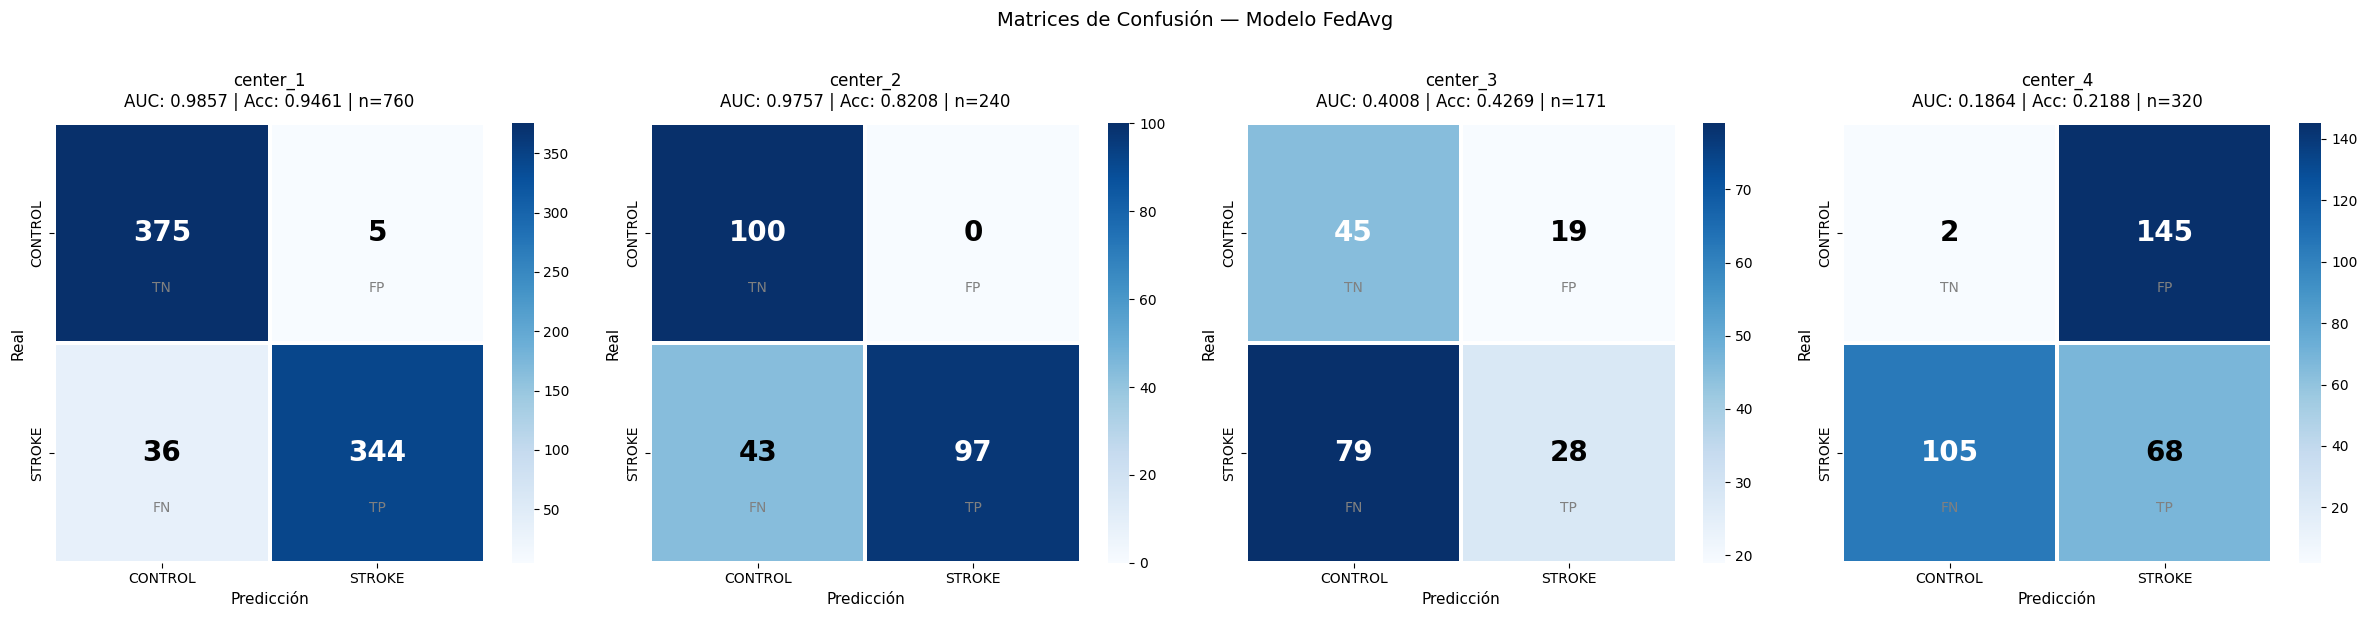

In [19]:
# Matriz de confusión por centro
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["cm"]

    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=["CONTROL", "STROKE"],
                yticklabels=["CONTROL", "STROKE"],
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=20, fontweight="bold", color=color)

    etiquetas = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                    ha="center", va="center",
                    fontsize=10, color="gray")

    n_test   = len(res["labels"])
    accuracy = res["accuracy"]
    ax.set_title(f"{nombre}\nAUC: {res['auc']:.4f} | Acc: {accuracy:.4f} | n={n_test}",
                 fontsize=12, pad=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión — Modelo FedAvg", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Predicciones con modelo FedAvg en Center 5
class StrokeDatasetTest(Dataset):
    def __init__(self, archivos):
        self.archivos = archivos

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        return torch.from_numpy(imagen), self.archivos[idx].stem


# Rutas
CENTER5_DIR = Path("../preprocesamiento/output/center_5/preprocesamiento_test")
PROB_DIR    = Path("probabilidades")
PROB_DIR.mkdir(exist_ok=True)

# Cargar modelo FedAvg
modelo_fedavg = crear_modelo().to(DEVICE)
modelo_fedavg.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_fedavg.eval()

# Dataset y loader center 5
archivos_c5 = sorted(CENTER5_DIR.glob("*.npy"))
dataset_c5  = StrokeDatasetTest(archivos_c5)
loader_c5   = DataLoader(dataset_c5, batch_size=BATCH_SIZE, shuffle=False)

print(f"Center 5 — archivos encontrados: {len(archivos_c5)}")

# Inferencia
nombres = []
probs   = []

with torch.no_grad():
    for imagenes, nombres_batch in loader_c5:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo_fedavg(imagenes)
        prob     = torch.sigmoid(salida).squeeze(1).cpu().numpy()

        nombres.extend(nombres_batch)
        probs.extend([round(float(p), 6) for p in prob])

# Guardar CSV
df       = pd.DataFrame({"archivo": nombres, "probabilidad": probs})
csv_path = PROB_DIR / "probabilidades_fedavg.csv"
df.to_csv(csv_path, index=False)

print(f"Guardado : {csv_path} | {len(df)} muestras")

Center 5 — archivos encontrados: 257
Guardado : probabilidades\probabilidades_fedavg.csv | 257 muestras


# **Entrenamiento Federado (FedProx)**

<h3><b> Entrenamiento local por centro (con FedProx)

In [21]:
# Modelo global
set_seed(SEED)
modelo_global = crear_modelo().to(DEVICE)

# Ruta donde guardar el mejor modelo global
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_fedprox_mejor.pth"

total_params = sum(p.numel() for p in modelo_global.parameters())
print(f"Parámetros : {total_params:,}")
print(f"Dispositivo: {DEVICE}")

Parámetros : 4,008,541
Dispositivo: cuda


In [22]:
def entrenar_centro(nombre, modelo_global, loader_train, loader_val, epochs, mu=0.3):
    
    modelo_local = copy.deepcopy(modelo_global)
    criterio     = LOSS_POR_CENTRO[nombre]
    optimizer    = torch.optim.AdamW(modelo_local.parameters(), lr=LR, weight_decay=1e-4)
    # Scheduler para reducir LR gradualmente
    scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Guardamos los pesos del modelo global como referencia (el punto de anclaje)
    pesos_ref = {k: v.clone().detach() for k, v in modelo_global.state_dict().items()}

    mejor_val_loss = float("inf")
    mejores_pesos  = None
    mejor_val_acc  = 0.0
    mejor_val_auc  = 0.0

    for epoca in range(epochs):
        modelo_local.train()
        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in loader_train:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()

            salida = modelo_local(imagenes)

            # Loss normal
            loss_normal = criterio(salida, labels)

            # Castigo proximal — distancia entre pesos locales y globales
            castigo = 0.0
            for k, param in modelo_local.named_parameters():
                if k in pesos_ref:
                    castigo += ((param - pesos_ref[k]) ** 2).sum()
            castigo = (mu / 2) * castigo

            # Loss total = loss normal + castigo
            loss_total = loss_normal + castigo

            loss_total.backward()
            # Gradient clipping para estabilidad
            torch.nn.utils.clip_grad_norm_(modelo_local.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss      += loss_normal.item()  # solo monitoreamos loss normal
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        modelo_local.eval()
        val_loss, val_correctos = 0.0, 0
        todas_probs  = []
        todos_labels = []

        with torch.no_grad():
            for imagenes, labels in loader_val:
                imagenes = imagenes.to(DEVICE)
                labels   = labels.to(DEVICE).unsqueeze(1)
                salida   = modelo_local(imagenes)
                loss     = criterio(salida, labels)
                probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()
                todas_probs.extend(probs)
                todos_labels.extend(labels.squeeze(1).cpu().numpy())

        train_loss /= len(loader_train)
        val_loss   /= len(loader_val)
        train_acc   = train_correctos / len(loader_train.dataset)
        val_acc     = val_correctos   / len(loader_val.dataset)
        val_auc     = roc_auc_score(todos_labels, todas_probs)

        # Actualizar LR con el scheduler
        scheduler.step()

        print(f"      [{nombre}] época {epoca+1:02d}/{epochs} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f} | auc: {val_auc:.4f}")

        if val_auc > mejor_val_auc:
            mejor_val_auc  = val_auc
            mejor_val_loss = val_loss
            mejor_val_acc  = val_acc
            mejores_pesos  = copy.deepcopy(modelo_local.state_dict())
            print(f"        → mejor época local: {epoca+1} | auc: {mejor_val_auc:.4f}")

    return mejores_pesos, mejor_val_loss, mejor_val_acc, mejor_val_auc

In [23]:
# Rondas federadas

# Variables para seguimiento de la mejor ronda global
mejor_val_global = 0.0
rondas_sin_mejora  = 0
total_muestras     = sum(d["n_train"] for d in datos_centros.values())

historial = {"ronda": [], "val_loss": []}

# Entrenamiento federado
for ronda in range(1, RONDAS + 1):

    print(f"\n{'='*60}")
    print(f"  RONDA {ronda}/{RONDAS}")
    print(f"{'='*60}")

    # Reiniciar generator al inicio de cada ronda
    g = torch.Generator()
    g.manual_seed(SEED + ronda)  # seed distinta pero fija por ronda

    # Recrear loader_train con el nuevo generator
    for nombre, datos in datos_centros.items():
        datos["loader_train"] = DataLoader(
            datos["loader_train"].dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            worker_init_fn=seed_worker,
            generator=g
        )

    pesos_centros    = []
    val_losses       = []
    val_accs         = []
    val_aucs = []
    muestras_centros = []

    # Entrenamiento local por centro
    for nombre, datos in datos_centros.items():
        print(f"\n  Centro: {nombre}")
        set_seed(SEED + ronda)
        pesos, val_loss, val_acc, val_auc = entrenar_centro(
            nombre,
            modelo_global,
            datos["loader_train"],
            datos["loader_val"],
            EPOCHS_LOCAL
        )
        pesos_centros.append(pesos)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
        muestras_centros.append(datos["n_train"])

    # FedAvg
    pesos_globales = agregar_pesos(pesos_centros, muestras_centros)
    modelo_global.load_state_dict(pesos_globales)

    # val global con AUC
    val_global = sum(
        va * (n / total_muestras)
        for va, n in zip(val_aucs, muestras_centros)
    )


    historial["ronda"].append(ronda)
    historial["val_loss"].append(val_global)

    print(f"\n  {'─'*55}")
    print(f"  Ronda {ronda} — val_loss global: {val_global:.4f}")


    # Guardar mejor modelo global
    if val_global > mejor_val_global: 

        mejor_val_global  = val_global
        rondas_sin_mejora = 0
        torch.save(modelo_global.state_dict(), MEJOR_MODELO_PATH)
        print(f"  Mejor modelo global guardado (val_loss: {mejor_val_global:.4f})")

    else:
        
        rondas_sin_mejora += 1
        print(f"  Sin mejora {rondas_sin_mejora}/{PACIENCIA}")

    # Early stopping
    if rondas_sin_mejora >= PACIENCIA:
        print(f"\n  Early stopping en ronda {ronda}")
        break


print(f"\n{'='*60}")
print(f"Entrenamiento federado finalizado")
print(f"Mejor val_loss global: {mejor_val_global:.4f}")
print(f"Modelo guardado en   : {MEJOR_MODELO_PATH}")


  RONDA 1/30

  Centro: center_1
      [center_1] época 01/20 — train_loss: 0.4046 acc: 0.8549 | val_loss: 0.2216 acc: 0.9408 | auc: 0.9853
        → mejor época local: 1 | auc: 0.9853
      [center_1] época 02/20 — train_loss: 0.2462 acc: 0.9276 | val_loss: 0.1698 acc: 0.9638 | auc: 0.9928
        → mejor época local: 2 | auc: 0.9928
      [center_1] época 03/20 — train_loss: 0.2000 acc: 0.9400 | val_loss: 0.1511 acc: 0.9671 | auc: 0.9951
        → mejor época local: 3 | auc: 0.9951
      [center_1] época 04/20 — train_loss: 0.2089 acc: 0.9334 | val_loss: 0.1805 acc: 0.9474 | auc: 0.9894
      [center_1] época 05/20 — train_loss: 0.1854 acc: 0.9391 | val_loss: 0.1371 acc: 0.9638 | auc: 0.9940
      [center_1] época 06/20 — train_loss: 0.1718 acc: 0.9420 | val_loss: 0.1437 acc: 0.9655 | auc: 0.9924
      [center_1] época 07/20 — train_loss: 0.1808 acc: 0.9445 | val_loss: 0.1559 acc: 0.9556 | auc: 0.9889
      [center_1] época 08/20 — train_loss: 0.1797 acc: 0.9383 | val_loss: 0.1420 a

<h3><b> Evaluación

In [24]:
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_fedprox_mejor.pth"

In [25]:
# Cargar el mejor modelo global para evaluación final
modelo_global.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_global.eval()

# Evaluación final en cada centro
def evaluar_centro(nombre, modelo, loader_test):
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes = imagenes.to(DEVICE)
            salida   = modelo(imagenes)
            probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds    = (probs >= 0.5).astype(int)

            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc          = roc_auc_score(todos_labels, todos_probs)
    f1           = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision    = precision_score(todos_labels, todos_preds)
    accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm           = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"         : auc,
        "f1"          : f1,
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "precision"   : precision,
        "accuracy"    : accuracy,
        "cm"          : cm,
        "labels"      : todos_labels,
        "preds"       : todos_preds,
    }


# Evaluar en cada centro
resultados = {}

for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_centro(nombre, modelo_global, datos["loader_test"])

# Metricas por centro
print(f"\n{'='*65}")
print(f"  EVALUACIÓN FINAL — TEST SET POR CENTRO")
print(f"{'='*65}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*65}")

metricas = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres  = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*65}")


  EVALUACIÓN FINAL — TEST SET POR CENTRO
Métrica              Center 1   Center 2   Center 3   Center 4
─────────────────────────────────────────────────────────────────
  AUC-ROC              0.9700     0.9687     0.4521     0.2038
  Accuracy             0.9132     0.7875     0.4854     0.2375
  F1-Score             0.9145     0.7773     0.3889     0.3545
  Sensibilidad         0.9289     0.6357     0.2617     0.3873
  Especificidad        0.8974     1.0000     0.8594     0.0612
  Precisión            0.9005     1.0000     0.7568     0.3268


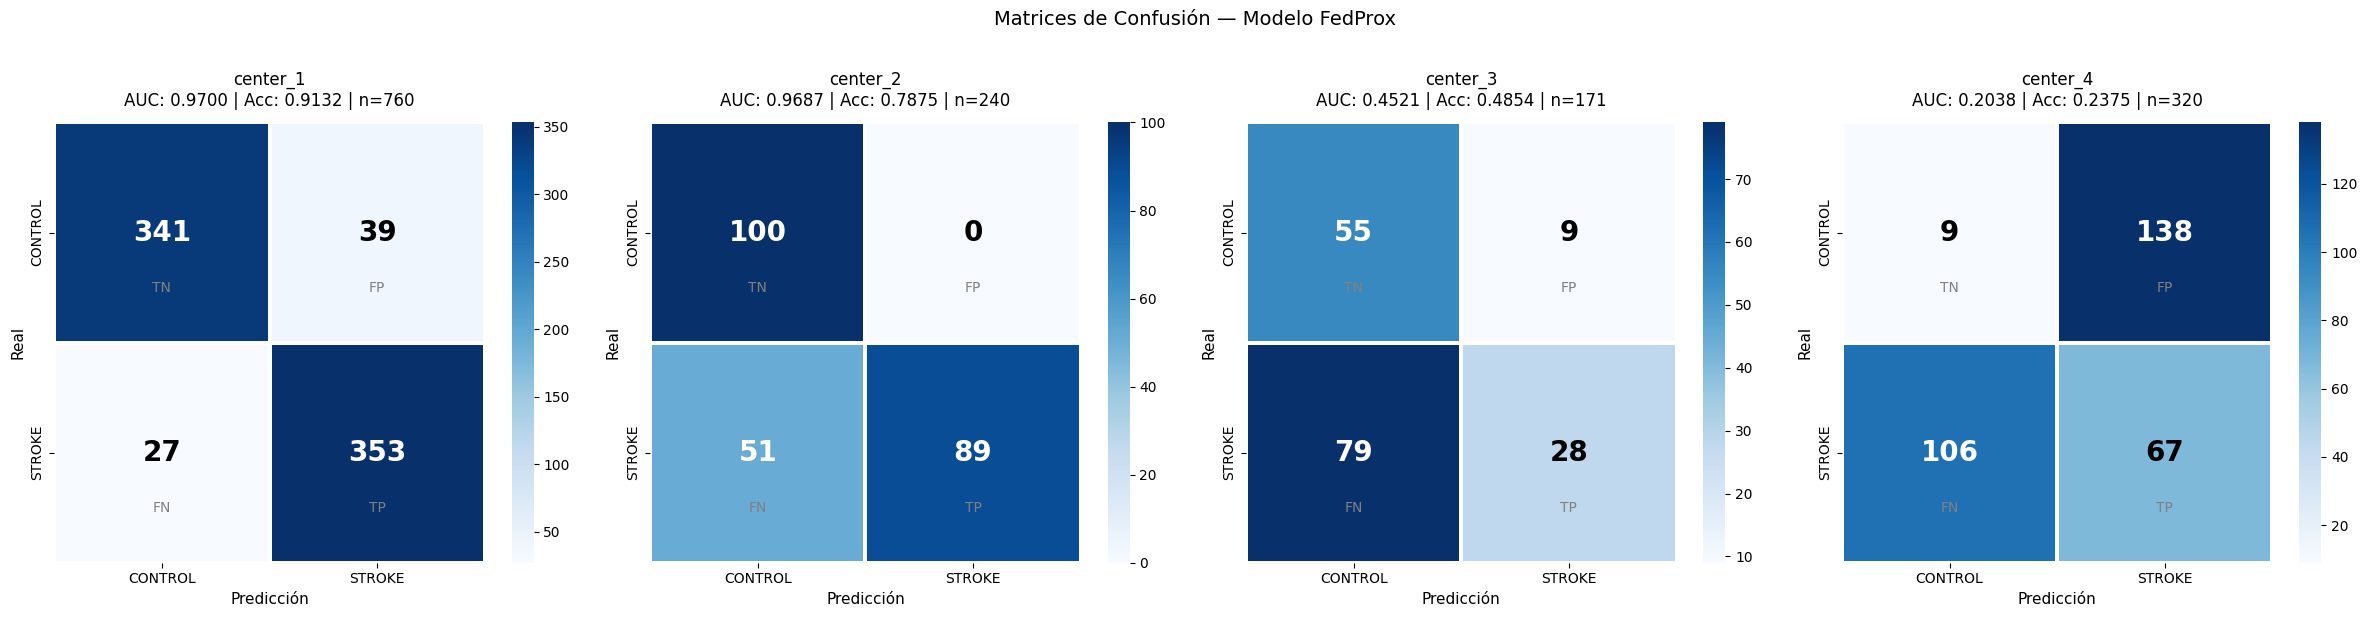

In [26]:
# Matriz de confusión por centro
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["cm"]

    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=["CONTROL", "STROKE"],
                yticklabels=["CONTROL", "STROKE"],
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=20, fontweight="bold", color=color)

    etiquetas = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                    ha="center", va="center",
                    fontsize=10, color="gray")

    n_test   = len(res["labels"])
    accuracy = res["accuracy"]
    ax.set_title(f"{nombre}\nAUC: {res['auc']:.4f} | Acc: {accuracy:.4f} | n={n_test}",
                 fontsize=12, pad=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión — Modelo FedProx", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_fedprox_mejor.pth"

In [10]:
# Predicciones con modelo FedAvg en Center 5
class StrokeDatasetTest(Dataset):
    def __init__(self, archivos):
        self.archivos = archivos

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        return torch.from_numpy(imagen), self.archivos[idx].stem


# Rutas
CENTER5_DIR = Path("../preprocesamiento/output/center_5/preprocesamiento_test")
PROB_DIR    = Path("probabilidades")
PROB_DIR.mkdir(exist_ok=True)

# Cargar modelo FedAvg
modelo_fedavg = crear_modelo().to(DEVICE)
modelo_fedavg.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_fedavg.eval()

# Dataset y loader center 5
archivos_c5 = sorted(CENTER5_DIR.glob("*.npy"))
dataset_c5  = StrokeDatasetTest(archivos_c5)
loader_c5   = DataLoader(dataset_c5, batch_size=BATCH_SIZE, shuffle=False)

print(f"Center 5 — archivos encontrados: {len(archivos_c5)}")

# Inferencia
nombres = []
probs   = []

with torch.no_grad():
    for imagenes, nombres_batch in loader_c5:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo_fedavg(imagenes)
        prob     = torch.sigmoid(salida).squeeze(1).cpu().numpy()

        nombres.extend(nombres_batch)
        probs.extend([round(float(p), 6) for p in prob])

# Guardar CSV
df       = pd.DataFrame({"archivo": nombres, "probabilidad": probs})
csv_path = PROB_DIR / "probabilidades_fedprox.csv"
df.to_csv(csv_path, index=False)

print(f"Guardado : {csv_path} | {len(df)} muestras")

Center 5 — archivos encontrados: 257
Guardado : probabilidades\probabilidades_fedprox.csv | 257 muestras


# **Entrenamiento Federado (FedAdaptativo)**

<h2> <b> Entrenamiento Federado

In [ ]:
# Modelo global
set_seed(SEED)
modelo_global = crear_modelo().to(DEVICE)

# Ruta donde guardar el mejor modelo global
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_fedadaptativo_mejor.pth"

total_params = sum(p.numel() for p in modelo_global.parameters())
print(f"Parámetros : {total_params:,}")
print(f"Dispositivo: {DEVICE}")

Parámetros : 11,173,889
Dispositivo: cuda


In [ ]:
# Rondas federadas
mejor_val_global   = float("inf")
rondas_sin_mejora  = 0
total_muestras     = sum(d["n_train"] for d in datos_centros.values())
historial          = {"ronda": [], "val_loss": []}

# Val losses de la ronda anterior — iniciamos en 1.0 (peor caso)
val_losses_anteriores = [1.0] * len(CENTROS)

for ronda in range(1, RONDAS + 1):
    print(f"\n{'='*60}")
    print(f"  RONDA {ronda}/{RONDAS}")
    print(f"{'='*60}")

    # Reiniciar generator al inicio de cada ronda
    g = torch.Generator()
    g.manual_seed(SEED + ronda)  # seed distinta pero fija por ronda

    # Recrear loader_train con el nuevo generator
    for nombre, datos in datos_centros.items():
        datos["loader_train"] = DataLoader(
            datos["loader_train"].dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            worker_init_fn=seed_worker,
            generator=g
        )

    pesos_centros    = []
    val_losses       = []
    val_accs         = []
    muestras_centros = []

    # Entrenamiento local por centro
    for nombre, datos in datos_centros.items():
        print(f"\n  Centro: {nombre}")
        set_seed(SEED + ronda)
        pesos, val_loss, val_acc = entrenar_centro(
            nombre,
            modelo_global,
            datos["loader_train"],
            datos["loader_val"],
            EPOCHS_LOCAL
        )
        pesos_centros.append(pesos)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        muestras_centros.append(datos["n_train"])

    # Agregación adaptativa — usa val_losses anterior y nuevo
    pesos_globales = agregar_pesos(
        pesos_centros,
        muestras_centros,
        val_losses_anteriores,  # ronda anterior
        val_losses              # ronda actual
    )
    modelo_global.load_state_dict(pesos_globales)

    # Mostrar contribución de cada centro  ← aquí
    print(f"\n  Contribución por centro esta ronda:")
    for nombre, n, vl_old, vl_new in zip(datos_centros.keys(), muestras_centros, val_losses_anteriores, val_losses):
        delta = (vl_old - vl_new) / (vl_old + 1e-8)
        ik    = math.sqrt(n) * (1 + delta)
        print(f"    {nombre} → Δ: {delta:.4f} | I: {ik:.4f}")

    # Actualizar val_losses anteriores para la siguiente ronda
    val_losses_anteriores = val_losses.copy()

    # Val global ponderada
    val_global = sum(
        (1 - va) * (n / total_muestras)
        for va, n in zip(val_accs, muestras_centros)
    )

    # Val global ponderada
    val_global = sum(
        (1 - va) * (n / total_muestras)
        for va, n in zip(val_accs, muestras_centros)
    )

    historial["ronda"].append(ronda)
    historial["val_loss"].append(val_global)

    print(f"\n  {'─'*55}")
    print(f"  Ronda {ronda} — val_loss global: {val_global:.4f}")

    if val_global < mejor_val_global:
        mejor_val_global  = val_global
        rondas_sin_mejora = 0
        torch.save(modelo_global.state_dict(), MEJOR_MODELO_PATH)
        print(f"  Mejor modelo global guardado (val_loss: {mejor_val_global:.4f})")
    else:
        rondas_sin_mejora += 1
        print(f"  Sin mejora {rondas_sin_mejora}/{PACIENCIA}")

    if rondas_sin_mejora >= PACIENCIA:
        print(f"\n  Early stopping en ronda {ronda}")
        break

print(f"\n{'='*60}")
print(f"Entrenamiento federado finalizado")
print(f"Mejor val_loss global: {mejor_val_global:.4f}")
print(f"Modelo guardado en   : {MEJOR_MODELO_PATH}")


  RONDA 1/30

  Centro: center_1
      [center_1] época 01/20 — train_loss: 0.2647 acc: 0.8869 | val_loss: 0.1204 acc: 0.9556
        → mejor época local: 1 | val_loss: 0.1204 | val_acc: 0.9556
      [center_1] época 02/20 — train_loss: 0.0531 acc: 0.9827 | val_loss: 0.0558 acc: 0.9803
        → mejor época local: 2 | val_loss: 0.0558 | val_acc: 0.9803
      [center_1] época 03/20 — train_loss: 0.0290 acc: 0.9914 | val_loss: 0.1001 acc: 0.9605
      [center_1] época 04/20 — train_loss: 0.0290 acc: 0.9889 | val_loss: 0.1410 acc: 0.9523
      [center_1] época 05/20 — train_loss: 0.0371 acc: 0.9881 | val_loss: 0.1110 acc: 0.9539
      [center_1] época 06/20 — train_loss: 0.0063 acc: 0.9992 | val_loss: 0.0309 acc: 0.9934
        → mejor época local: 6 | val_loss: 0.0309 | val_acc: 0.9934
      [center_1] época 07/20 — train_loss: 0.0170 acc: 0.9955 | val_loss: 0.0532 acc: 0.9819
      [center_1] época 08/20 — train_loss: 0.0038 acc: 0.9996 | val_loss: 0.0358 acc: 0.9885
      [center_1] é

<h2><b>Evaluación

In [60]:
# Cargar el mejor modelo global para evaluación final
modelo_global.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_global.eval()

# Evaluación final en cada centro
def evaluar_centro(nombre, modelo, loader_test):
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes = imagenes.to(DEVICE)
            salida   = modelo(imagenes)
            probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds    = (probs >= 0.5).astype(int)

            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc          = roc_auc_score(todos_labels, todos_probs)
    f1           = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision    = precision_score(todos_labels, todos_preds)
    accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm           = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"         : auc,
        "f1"          : f1,
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "precision"   : precision,
        "accuracy"    : accuracy,
        "cm"          : cm,
        "labels"      : todos_labels,
        "preds"       : todos_preds,
    }


# Evaluar en cada centro
resultados = {}

for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_centro(nombre, modelo_global, datos["loader_test"])

# Metricas por centro
print(f"\n{'='*65}")
print(f"  EVALUACIÓN FINAL — TEST SET POR CENTRO")
print(f"{'='*65}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*65}")

metricas = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres  = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*65}")


  EVALUACIÓN FINAL — TEST SET POR CENTRO
Métrica              Center 1   Center 2   Center 3   Center 4
─────────────────────────────────────────────────────────────────
  AUC-ROC              0.9310     0.9330     0.1837     0.3624
  Accuracy             0.8434     0.8875     0.3216     0.4219
  F1-Score             0.8518     0.9032     0.4821     0.5708
  Sensibilidad         0.9000     0.9000     0.5047     0.7110
  Especificidad        0.7868     0.8700     0.0156     0.0816
  Precisión            0.8085     0.9065     0.4615     0.4767


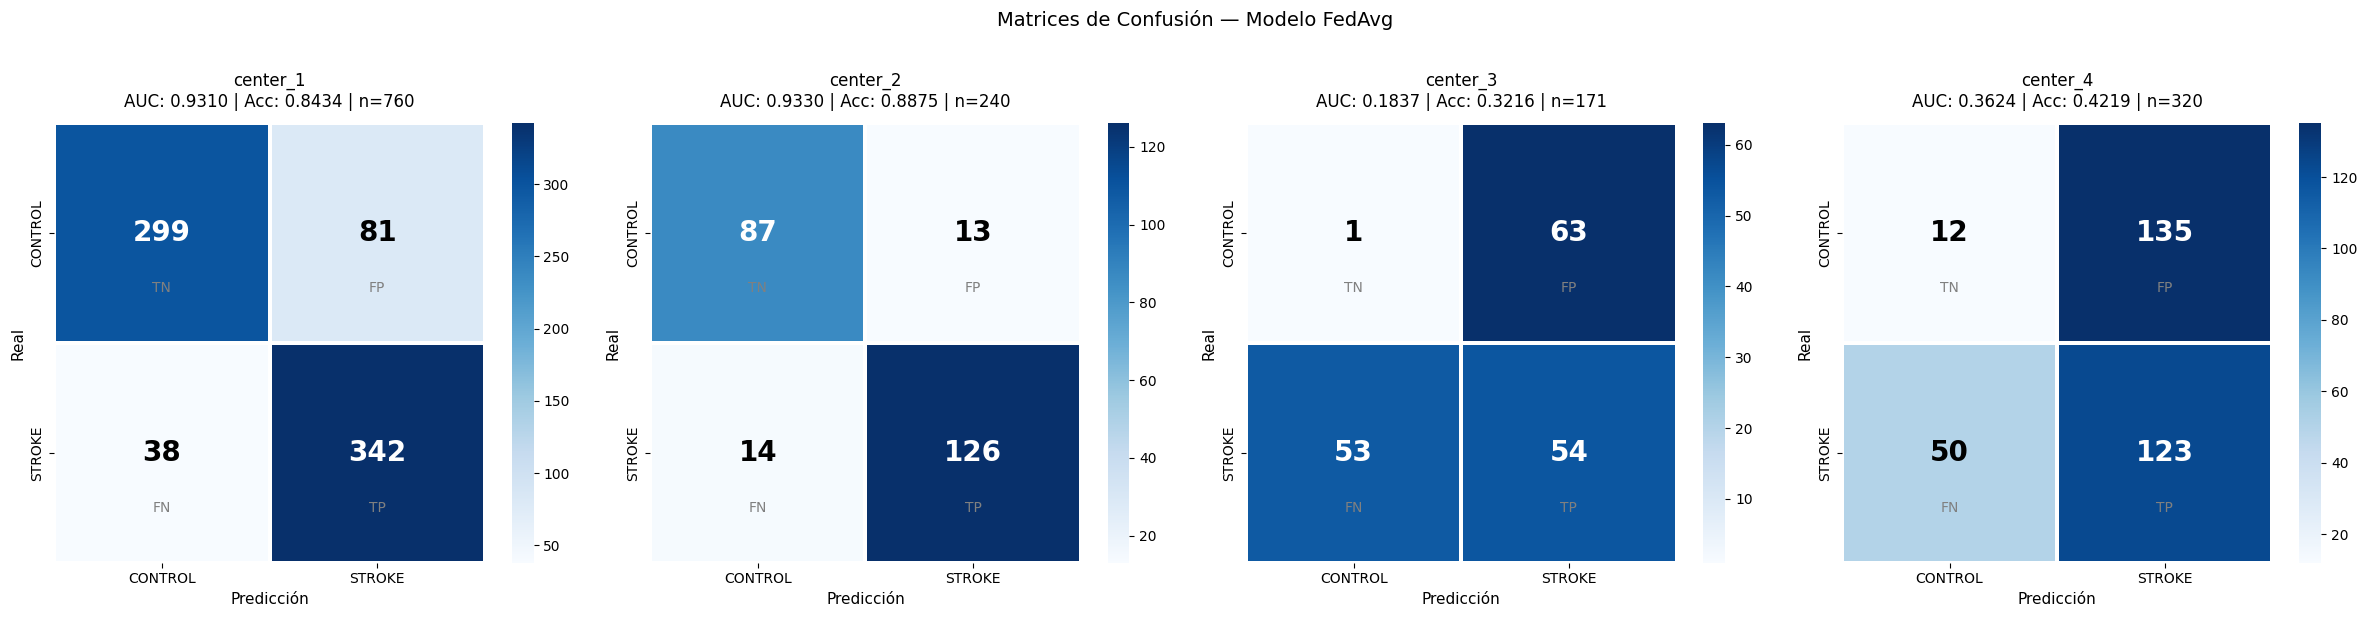

In [61]:
# Matriz de confusión por centro
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["cm"]

    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=["CONTROL", "STROKE"],
                yticklabels=["CONTROL", "STROKE"],
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=20, fontweight="bold", color=color)

    etiquetas = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                    ha="center", va="center",
                    fontsize=10, color="gray")

    n_test   = len(res["labels"])
    accuracy = res["accuracy"]
    ax.set_title(f"{nombre}\nAUC: {res['auc']:.4f} | Acc: {accuracy:.4f} | n={n_test}",
                 fontsize=12, pad=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión — Modelo FedAvg", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()